In [1]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
train = pd.read_csv("data/RingSynTrain.csv")
test = pd.read_csv("data/RingSynTest.csv")

X_train = train[["feature1", "feature2"]].values
y_train = train["class"].values

X_test = test[["feature1", "feature2"]].values
y_test = test["class"].values

# Store results
hidden_sizes = range(4, 11)
train_accuracies = []
test_accuracies = []

# Train MLPs with 4 to 10 hidden neurons
for size in hidden_sizes:

    mlp = MLPClassifier(
        hidden_layer_sizes=(size,),
        activation="relu",
        solver="adam",
        max_iter=10000,
        random_state=42
    )

    mlp.fit(X_train, y_train)

    train_predictions = mlp.predict(X_train)
    test_predictions = mlp.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(
        f"Hidden neurons: {size}, "
        f"Training Accuracy: {train_accuracy:.4f}, "
        f"Test Accuracy: {test_accuracy:.4f}"
    )

Hidden neurons: 4, Training Accuracy: 0.9183, Test Accuracy: 0.9133
Hidden neurons: 5, Training Accuracy: 0.9117, Test Accuracy: 0.9333
Hidden neurons: 6, Training Accuracy: 0.9183, Test Accuracy: 0.9233
Hidden neurons: 7, Training Accuracy: 0.9205, Test Accuracy: 0.9233
Hidden neurons: 8, Training Accuracy: 0.9227, Test Accuracy: 0.9233
Hidden neurons: 9, Training Accuracy: 0.9205, Test Accuracy: 0.9433
Hidden neurons: 10, Training Accuracy: 0.9183, Test Accuracy: 0.9100


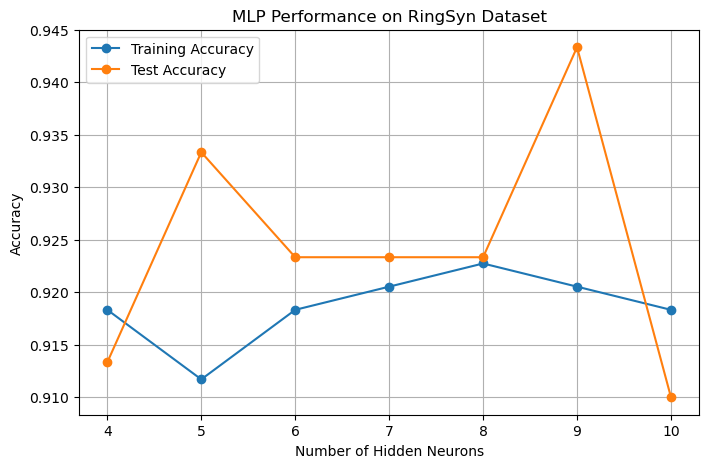

In [2]:
plt.figure(figsize=(8, 5))

plt.plot(
    hidden_sizes,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    hidden_sizes,
    test_accuracies,
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Number of Hidden Neurons")
plt.ylabel("Accuracy")
plt.title("MLP Performance on RingSyn Dataset")
plt.xticks(list(hidden_sizes))
plt.legend()
plt.grid(True)
plt.savefig("MLPPerform")
plt.show()